# FASE 1 — Auditoria dos Dados
**Challenge 002 — Redesign de Suporte (G4 Educação)** · Autor: Thales Barbosa · 2026-07-16

Auditoria completa dos dois datasets: schema, tipos, nulos, duplicados, cardinalidade, estatísticas,
distribuições, inconsistências e **análise especial** das colunas `First Response Time` e `Time to Resolution`
(teste das Hipóteses A e B definidas no plano).

**Reprodutibilidade:** execute a partir da pasta `notebooks/` com o venv do projeto
(`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`). Os gráficos são salvos em `docs/assets/`.
As conclusões estão consolidadas em `docs/data_audit.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
BLUE = sns.color_palette("deep")[0]

DATA = Path("../data")
ASSETS = Path("../docs/assets")
ASSETS.mkdir(parents=True, exist_ok=True)

d1 = pd.read_csv(DATA / "customer_support_tickets.csv")
d2 = pd.read_csv(DATA / "it_service_ticket_classification.csv")
print("Dataset 1 (customer_support_tickets):", d1.shape)
print("Dataset 2 (it_service_ticket_classification):", d2.shape)

Dataset 1 (customer_support_tickets): (8469, 17)
Dataset 2 (it_service_ticket_classification): (47837, 2)


---
## 1. Dataset 1 — `customer_support_tickets.csv`
### 1.1 Schema, tipos, nulos e cardinalidade

In [2]:
schema = pd.DataFrame({
    "dtype": d1.dtypes.astype(str),
    "nulos": d1.isna().sum(),
    "%_nulos": (d1.isna().mean() * 100).round(2),
    "cardinalidade": d1.nunique(),
})
schema

,dtype,nulos,%_nulos,cardinalidade
Ticket ID,int64,0,0.00,8469
Customer Name,str,0,0.00,8028
Customer Email,str,0,0.00,8320
Customer Age,int64,0,0.00,53
Customer Gender,str,0,0.00,3
Product Purchased,str,0,0.00,42
Date of Purchase,str,0,0.00,730
Ticket Type,str,0,0.00,5
Ticket Subject,str,0,0.00,16
Ticket Description,str,0,0.00,8077


In [3]:
print("Linhas 100% duplicadas:", d1.duplicated().sum())
print("Ticket ID duplicados:", d1["Ticket ID"].duplicated().sum())
print("Ticket Description duplicadas (texto exato):", d1["Ticket Description"].duplicated().sum())
print("Customer Email repetidos:", d1["Customer Email"].duplicated().sum(),
      "(clientes recorrentes ou colisão de gerador sintético)")

Linhas 100% duplicadas: 0
Ticket ID duplicados: 0
Ticket Description duplicadas (texto exato): 392
Customer Email repetidos: 149 (clientes recorrentes ou colisão de gerador sintético)


**Leitura:** não há duplicatas de linha nem de `Ticket ID`. Os nulos se concentram em 4 colunas
(`Resolution`, `Time to Resolution`, `Customer Satisfaction Rating` = 67,3%; `First Response Time` = 33,3%) —
a seção 1.4 mostra que esse padrão é 100% estrutural (depende do `Ticket Status`), não é sujeira aleatória.

### 1.2 Distribuições das variáveis categóricas

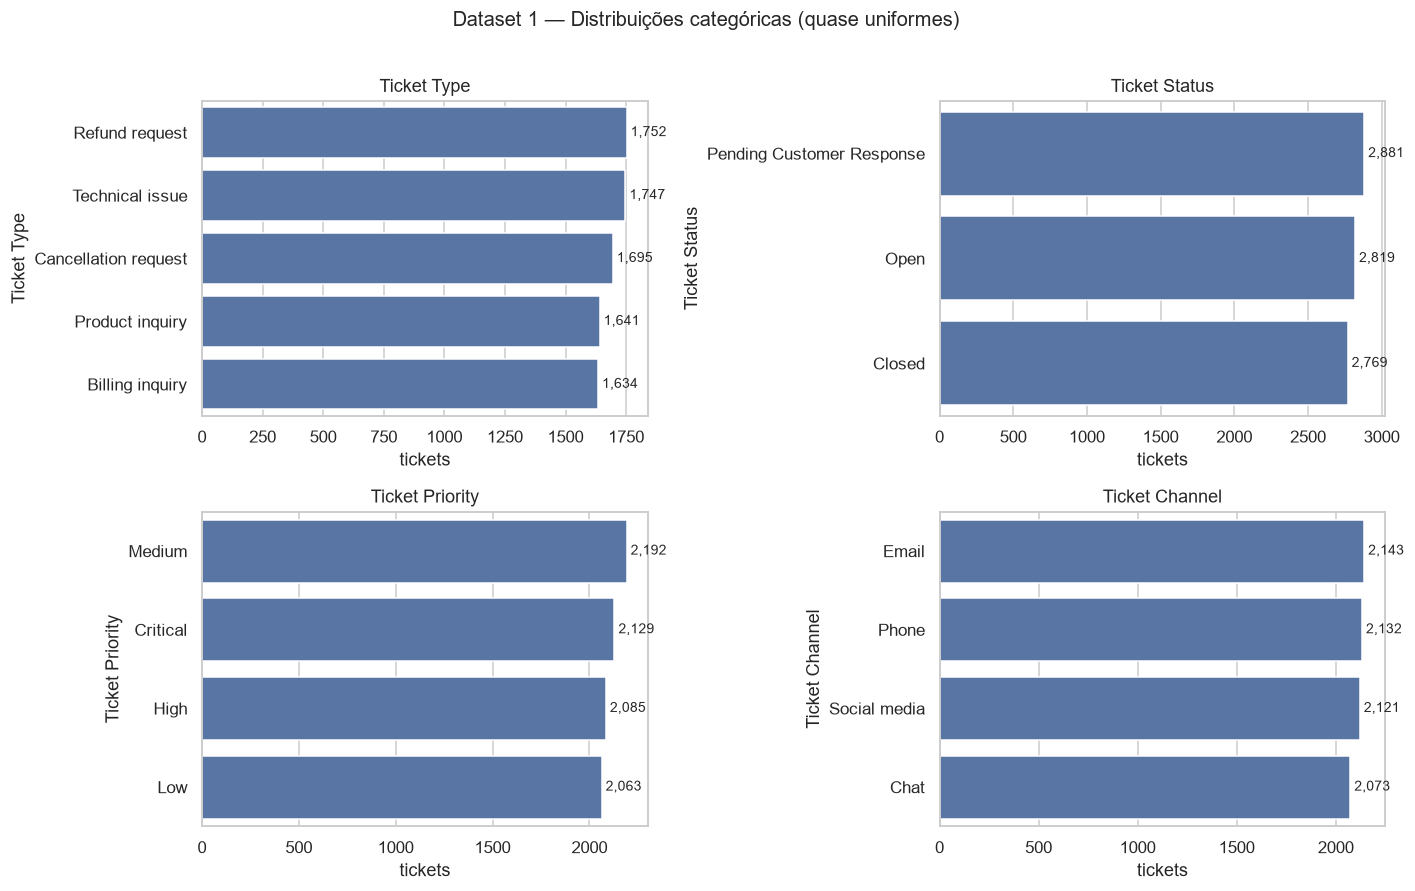

Ticket Type: 1,634-1,752 por nível | chi2 uniformidade p=0.115
Ticket Status: 2,769-2,881 por nível | chi2 uniformidade p=0.328
Ticket Priority: 2,063-2,192 por nível | chi2 uniformidade p=0.205
Ticket Channel: 2,073-2,143 por nível | chi2 uniformidade p=0.718


In [4]:
cats = ["Ticket Type", "Ticket Status", "Ticket Priority", "Ticket Channel"]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.ravel(), cats):
    vc = d1[c].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax, color=BLUE)
    ax.set_title(c)
    ax.set_xlabel("tickets")
    for i, v in enumerate(vc.values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
fig.suptitle("Dataset 1 — Distribuições categóricas (quase uniformes)", y=1.01, fontsize=13)
fig.tight_layout()
fig.savefig(ASSETS / "d1_categorical_distributions.png", bbox_inches="tight")
plt.show()

for c in cats:
    vc = d1[c].value_counts()
    chi2, p = stats.chisquare(vc.values)
    print(f"{c}: {vc.min():,}-{vc.max():,} por nível | chi2 uniformidade p={p:.3f}")

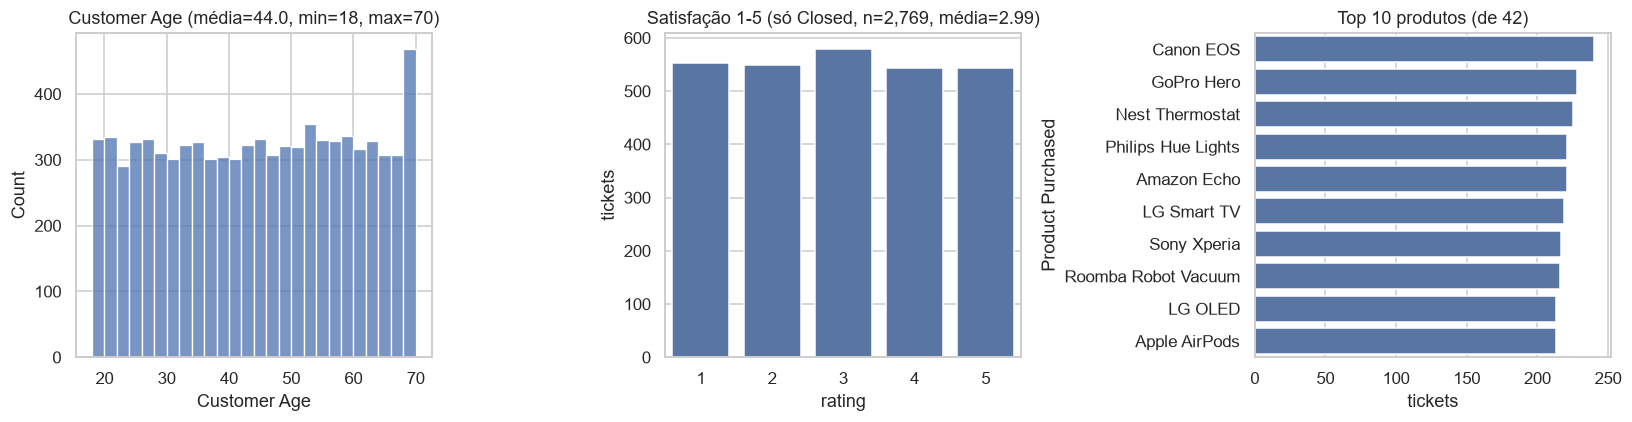

Satisfação: chi2 de uniformidade p=0.797 -> distribuição compatível com uniforme (média ~3,0)
count    8469.0
mean       44.0
std        15.3
min        18.0
25%        31.0
50%        44.0
75%        57.0
max        70.0
Name: Customer Age, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(d1["Customer Age"], bins=26, ax=axes[0], color=BLUE)
axes[0].set_title(f"Customer Age (média={d1['Customer Age'].mean():.1f}, min={d1['Customer Age'].min()}, max={d1['Customer Age'].max()})")

sat = d1["Customer Satisfaction Rating"].value_counts().sort_index()
sns.barplot(x=sat.index.astype(int), y=sat.values, ax=axes[1], color=BLUE)
axes[1].set_title(f"Satisfação 1-5 (só Closed, n={int(sat.sum()):,}, média={d1['Customer Satisfaction Rating'].mean():.2f})")
axes[1].set_xlabel("rating"); axes[1].set_ylabel("tickets")

prod = d1["Product Purchased"].value_counts().head(10)
sns.barplot(x=prod.values, y=prod.index, ax=axes[2], color=BLUE)
axes[2].set_title(f"Top 10 produtos (de {d1['Product Purchased'].nunique()})")
axes[2].set_xlabel("tickets")
fig.tight_layout()
fig.savefig(ASSETS / "d1_age_satisfaction.png", bbox_inches="tight")
plt.show()

chi2, p = stats.chisquare(sat.values)
print(f"Satisfação: chi2 de uniformidade p={p:.3f} -> distribuição compatível com uniforme (média ~3,0)")
print(d1["Customer Age"].describe().round(1))

**Leitura:** todas as categóricas são **quase perfeitamente uniformes** (testes qui-quadrado não rejeitam
uniformidade) e a satisfação é uniforme entre 1 e 5 (média 2,99). Em uma operação real, esperaríamos assimetrias
fortes (ex.: mais tickets de baixa prioridade do que críticos, satisfação concentrada em 4-5). Primeira evidência
de **dados sintéticos gerados por sorteio uniforme**.

### 1.3 Estatísticas numéricas

In [6]:
d1.describe(include=[np.number]).round(2)

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.00,8469.00,2769.00
mean,4235.00,44.03,2.99
std,2444.93,15.30,1.41
min,1.00,18.00,1.00
25%,2118.00,31.00,2.00
50%,4235.00,44.00,3.00
75%,6352.00,57.00,4.00
max,8469.00,70.00,5.00


### 1.4 Padrão de nulos por status (estrutural, não aleatório)

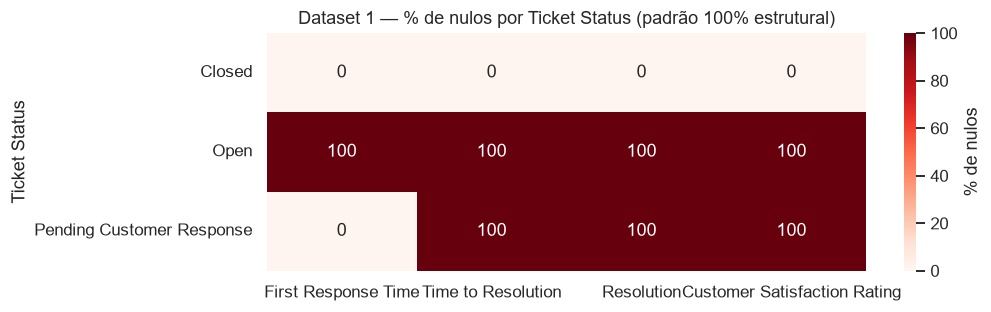

,First Response Time,Time to Resolution,Resolution,Customer Satisfaction Rating
Ticket Status,,,,
Closed,0.0,0.0,0.0,0.0
Open,100.0,100.0,100.0,100.0
Pending Customer Response,0.0,100.0,100.0,100.0


In [7]:
null_cols = ["First Response Time", "Time to Resolution", "Resolution", "Customer Satisfaction Rating"]
pct_null = d1.groupby("Ticket Status")[null_cols].apply(lambda g: g.isna().mean() * 100).round(1)

plt.figure(figsize=(9.5, 3))
sns.heatmap(pct_null, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% de nulos"})
plt.title("Dataset 1 — % de nulos por Ticket Status (padrão 100% estrutural)")
plt.tight_layout()
plt.savefig(ASSETS / "d1_nulls_by_status.png", bbox_inches="tight")
plt.show()
pct_null

**Leitura:** o padrão é determinístico — `Open` não tem FRT/TTR/Resolution/Satisfação;
`Pending Customer Response` tem apenas FRT; `Closed` tem tudo. Implicações:

1. Qualquer análise de satisfação ou de tempo de resolução usa **apenas os 2.769 tickets Closed** (32,7% da base).
2. Os nulos **não devem ser imputados** — são "não se aplica", não "faltou coletar".

---
## 2. ANÁLISE ESPECIAL — `First Response Time` e `Time to Resolution`

O plano exige testar, sem assumir significado:

- **Hipótese A:** `Time to Resolution` representa o tempo **total** (da abertura à resolução).
- **Hipótese B:** `Time to Resolution` representa o tempo **após a primeira resposta**.

### 2.1 O que as colunas contêm de fato

In [8]:
frt = pd.to_datetime(d1["First Response Time"], errors="coerce")
ttr = pd.to_datetime(d1["Time to Resolution"], errors="coerce")

print("Exemplo bruto:")
print(d1.loc[2:4, ["Ticket Status", "First Response Time", "Time to Resolution"]].to_string(), "\n")
print(f"FRT: {frt.notna().sum():,} valores | 0 falhas de parse | range {frt.min()} -> {frt.max()}")
print(f"TTR: {ttr.notna().sum():,} valores | 0 falhas de parse | range {ttr.min()} -> {ttr.max()}")
print("\nDias distintos - FRT:", frt.dt.date.nunique(), "| TTR:", ttr.dt.date.nunique())
print("\nDistribuição por data (FRT):")
print(frt.dt.date.value_counts().to_string())

Exemplo bruto:
  Ticket Status  First Response Time   Time to Resolution
2        Closed  2023-06-01 11:14:38  2023-06-01 18:05:38
3        Closed  2023-06-01 07:29:40  2023-06-01 01:57:40
4        Closed  2023-06-01 00:12:42  2023-06-01 19:53:42 

FRT: 5,650 valores | 0 falhas de parse | range 2023-05-31 21:55:39 -> 2023-06-02 00:54:21
TTR: 2,769 valores | 0 falhas de parse | range 2023-05-31 21:53:30 -> 2023-06-02 00:55:33

Dias distintos - FRT: 3 | TTR: 3

Distribuição por data (FRT):
First Response Time
2023-06-01    5437
2023-05-31     175
2023-06-02      38


**Constatação central: as colunas são TIMESTAMPS (data-hora), não durações** — e todos os
5.650 FRT / 2.769 TTR caem em apenas **3 dias** (31/mai a 02/jun/2023), ~96% em 01/jun/2023.
O dataset **não tem timestamp de abertura do ticket** (`Date of Purchase` é a data da compra do produto,
518 a 1.248 dias antes), logo **nenhuma duração real é calculável a partir da abertura**.

### 2.2 Teste das hipóteses: TTR − FRT

In [9]:
mask = frt.notna() & ttr.notna()  # = tickets Closed
delta_h = (ttr[mask] - frt[mask]).dt.total_seconds() / 3600

neg = (delta_h < 0).sum()
print(f"Tickets com FRT e TTR: {mask.sum():,}")
print(f"TTR ANTERIOR ao FRT (delta negativo): {neg:,} ({neg / mask.sum() * 100:.1f}%)")
print(f"\nDelta em horas — describe:\n{delta_h.describe().round(2)}")
print("\nPercentis [1,5,25,50,75,95,99]:", np.percentile(delta_h, [1, 5, 25, 50, 75, 95, 99]).round(2))

r_pearson = np.corrcoef(frt[mask].astype("int64"), ttr[mask].astype("int64"))[0, 1]
r_spear = stats.spearmanr(frt[mask].astype("int64"), ttr[mask].astype("int64")).statistic
print(f"\nCorrelação FRT vs TTR: Pearson={r_pearson:.4f} | Spearman={r_spear:.4f} (≈ zero)")

Tickets com FRT e TTR: 2,769
TTR ANTERIOR ao FRT (delta negativo): 1,365 (49.3%)

Delta em horas — describe:
count    2769.00
mean       -0.06
std         9.56
min       -23.23
25%        -6.93
50%         0.17
75%         6.48
max        23.47
dtype: float64

Percentis [1,5,25,50,75,95,99]: [-20.55 -16.22  -6.93   0.17   6.48  16.06  20.26]

Correlação FRT vs TTR: Pearson=0.0563 | Spearman=0.0549 (≈ zero)


In [10]:
dop = pd.to_datetime(d1["Date of Purchase"], errors="coerce")
m2 = frt.notna() & dop.notna()
gap_d = (frt[m2] - dop[m2]).dt.total_seconds() / 86400
print("Coerência com Date of Purchase:")
print(f"  FRT antes da compra: {(frt[m2] < dop[m2]).sum()} de {m2.sum():,}")
print(f"  gap compra -> FRT (dias): min={gap_d.min():.0f}, mediana={gap_d.median():.0f}, max={gap_d.max():.0f}")

Coerência com Date of Purchase:
  FRT antes da compra: 0 de 5,650
  gap compra -> FRT (dias): min=518, mediana=886, max=1248


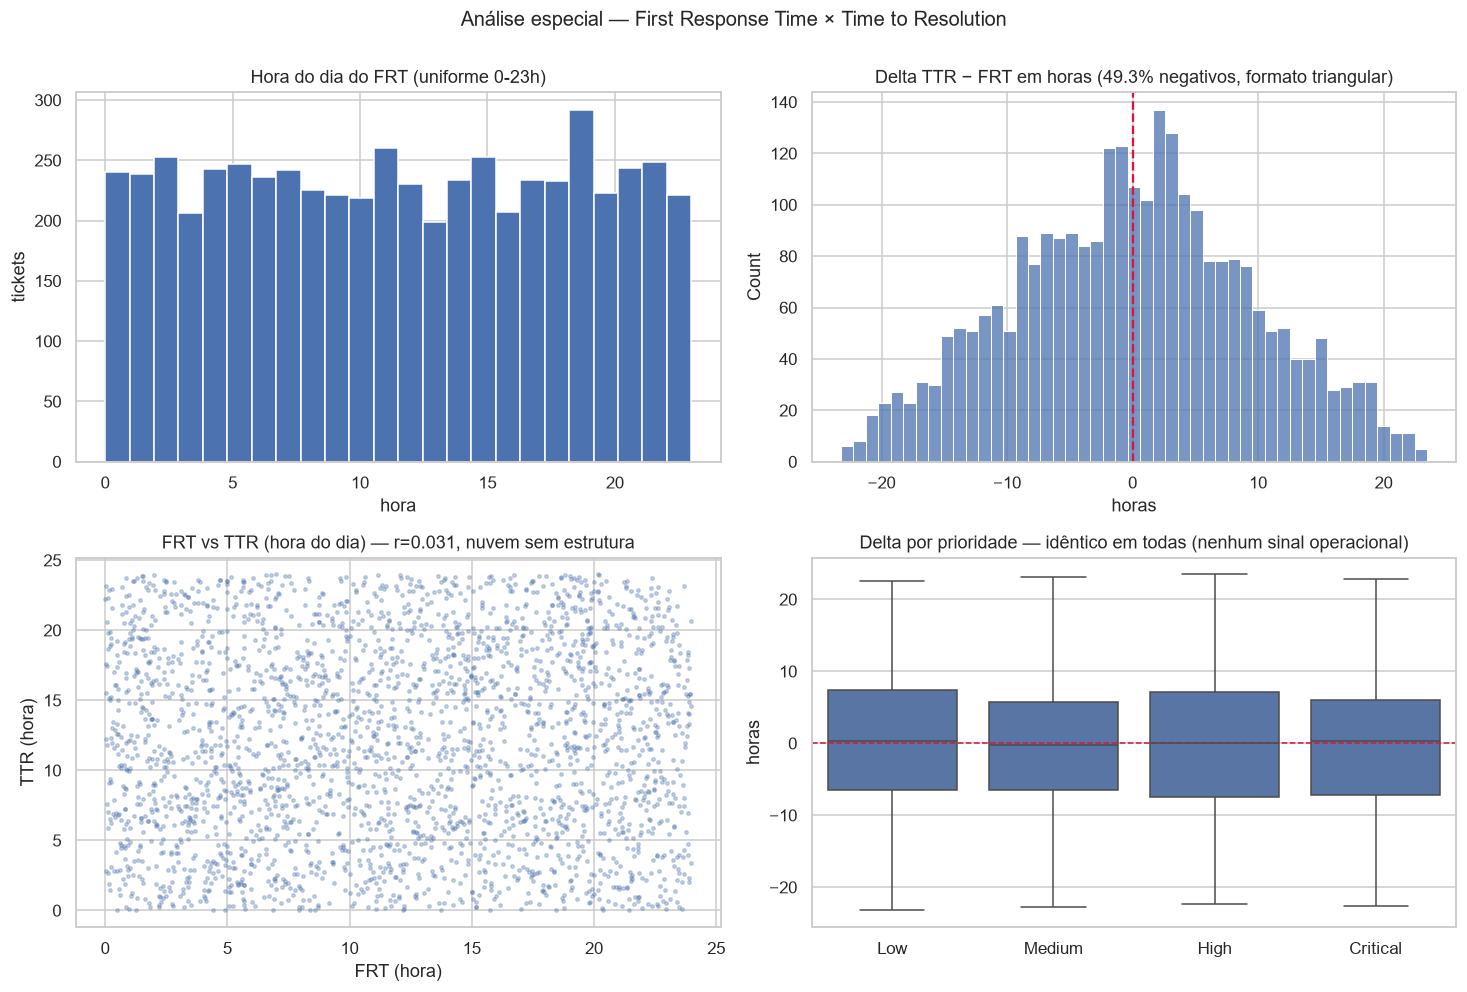

Mediana do delta por prioridade (h):
Ticket Priority
Critical    0.35
High        0.07
Low         0.35
Medium     -0.30


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))

axes[0, 0].hist(frt.dt.hour.dropna(), bins=24, color=BLUE, edgecolor="white")
axes[0, 0].set_title("Hora do dia do FRT (uniforme 0-23h)")
axes[0, 0].set_xlabel("hora"); axes[0, 0].set_ylabel("tickets")

sns.histplot(delta_h, bins=47, ax=axes[0, 1], color=BLUE)
axes[0, 1].axvline(0, color="crimson", ls="--", lw=1.5)
axes[0, 1].set_title(f"Delta TTR − FRT em horas ({(delta_h < 0).mean() * 100:.1f}% negativos, formato triangular)")
axes[0, 1].set_xlabel("horas")

frt_h = frt[mask].dt.hour + frt[mask].dt.minute / 60
ttr_h = ttr[mask].dt.hour + ttr[mask].dt.minute / 60
axes[1, 0].scatter(frt_h, ttr_h, s=5, alpha=0.3, color=BLUE)
axes[1, 0].set_title(f"FRT vs TTR (hora do dia) — r={np.corrcoef(frt_h, ttr_h)[0, 1]:.3f}, nuvem sem estrutura")
axes[1, 0].set_xlabel("FRT (hora)"); axes[1, 0].set_ylabel("TTR (hora)")

order = ["Low", "Medium", "High", "Critical"]
sns.boxplot(x=d1.loc[mask, "Ticket Priority"], y=delta_h, order=order, ax=axes[1, 1], color=BLUE)
axes[1, 1].axhline(0, color="crimson", ls="--", lw=1)
axes[1, 1].set_title("Delta por prioridade — idêntico em todas (nenhum sinal operacional)")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("horas")

fig.suptitle("Análise especial — First Response Time × Time to Resolution", y=1.0, fontsize=13)
fig.tight_layout()
fig.savefig(ASSETS / "d1_frt_ttr_analysis.png", bbox_inches="tight")
plt.show()

print("Mediana do delta por prioridade (h):")
print(delta_h.groupby(d1.loc[mask, "Ticket Priority"]).median().round(2).to_string())

### 2.3 Veredito das hipóteses

| Hipótese | Teste | Resultado |
|---|---|---|
| **B** — TTR = tempo após a 1ª resposta | exigiria TTR ≥ FRT sempre | ❌ **Rejeitada**: TTR < FRT em **49,3%** dos casos |
| **A** — TTR = tempo total desde a abertura | exigiria timestamp de abertura e ordem coerente | ❌ **Não sustentável**: não existe data de abertura no dataset; e um TTR "total" ainda deveria ser ≥ FRT, o que falha em metade dos casos |

**Diagnóstico (evidências convergentes):** FRT e TTR são **horários aleatórios independentes sorteados
no mesmo dia** (~01/jun/2023):

1. Delta TTR−FRT simétrico em torno de 0, com formato **triangular** em ±24h — exatamente a distribuição
   da diferença de duas variáveis uniformes independentes;
2. Correlação FRT×TTR ≈ 0,06 (deveria ser fortemente positiva em processo real);
3. Hora do dia uniforme 0-23h (sem horário comercial);
4. 3 dias de calendário para 8.469 tickets de "um ano" de operação;
5. Delta idêntico entre prioridades (Critical deveria resolver mais rápido que Low).

**Consequência para o projeto (limitação maior):** as colunas de tempo do Dataset 1 **não medem tempo
operacional real**. Métricas de duração derivadas delas (ex.: "tempo médio de resolução por canal") serão
ruído estatístico. As fases 2-3 deverão tratá-las como sintéticas e ancorar o diagnóstico em sinais válidos
(volumes, mix por canal/tipo/prioridade, status e satisfação) + benchmarks externos declarados para tempos.

---
## 3. Qualidade do texto do Dataset 1

In [12]:
ph = d1["Ticket Description"].str.contains(r"\{product_purchased\}", regex=True, na=False).sum()
first_sent = d1["Ticket Description"].str.split(".").str[0]
print(f"Descrições com placeholder literal {{product_purchased}}: {ph:,} de {len(d1):,} ({ph / len(d1) * 100:.0f}%)")
print("Ticket Subject únicos:", d1["Ticket Subject"].nunique(), "(para 8.469 tickets)")
print("Primeira frase da descrição — únicas:", first_sent.nunique(), "(descrições são templates)")
print("Descrições 100% idênticas:", d1["Ticket Description"].duplicated().sum())
print("Resolution únicos:", d1["Resolution"].nunique(), "| nulos:", d1["Resolution"].isna().sum())
print("\nExemplo de descrição:\n---")
print(d1.loc[0, "Ticket Description"][:400])

Descrições com placeholder literal {product_purchased}: 8,469 de 8,469 (100%)
Ticket Subject únicos: 16 (para 8.469 tickets)
Primeira frase da descrição — únicas: 16 (descrições são templates)
Descrições 100% idênticas: 392
Resolution únicos: 2769 | nulos: 5700

Exemplo de descrição:
---
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.


**Leitura:** 100% das descrições contêm o placeholder literal `{product_purchased}` e existem só
**16 aberturas de texto distintas** — o corpo é template + frases desconexas. O texto do Dataset 1 serve para
**demonstração de pipeline**, mas não para treinar classificador (o Dataset 2, com texto real, cumpre esse papel).

## 4. Correlações numéricas (Dataset 1, tickets Closed)

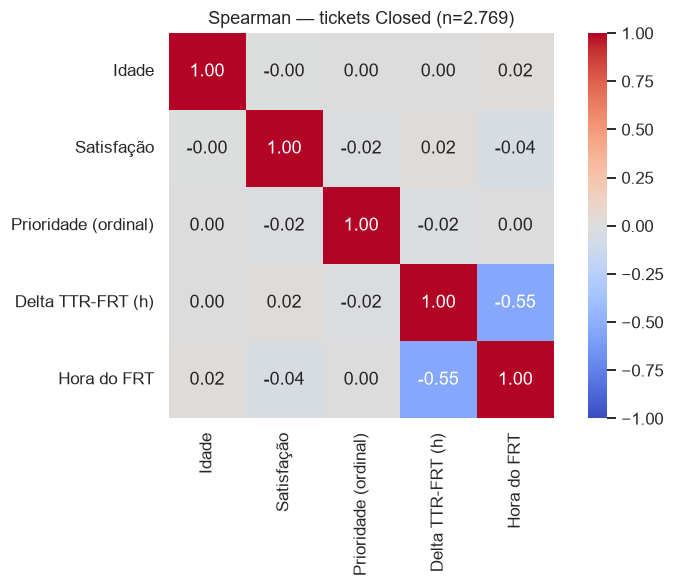

In [13]:
closed = d1[mask].copy()
prio_ord = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
corr_df = pd.DataFrame({
    "Idade": closed["Customer Age"],
    "Satisfação": closed["Customer Satisfaction Rating"],
    "Prioridade (ordinal)": closed["Ticket Priority"].map(prio_ord),
    "Delta TTR-FRT (h)": delta_h,
    "Hora do FRT": frt[mask].dt.hour,
})
corr = corr_df.corr(method="spearman").round(3)

plt.figure(figsize=(7.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Spearman — tickets Closed (n=2.769)")
plt.tight_layout()
plt.savefig(ASSETS / "d1_corr_heatmap.png", bbox_inches="tight")
plt.show()

**Leitura:** todos os pares com relevância de negócio (satisfação × idade/prioridade/delta/hora)
ficam em |ρ| ≤ 0,04 — consistente com variáveis sorteadas de forma independente. A única correlação forte,
**delta × hora do FRT (ρ = −0,55), é um artefato mecânico**: com TTR sorteado uniformemente no mesmo dia,
quanto mais tarde o FRT, mais negativo o delta tende a ser — mais uma evidência de que os tempos são sintéticos,
e não sinal operacional. A modelagem de drivers de satisfação (FASE 3) deverá reportar esse resultado
honestamente (a ausência de relação também é um resultado, e muda a recomendação executiva).

---
## 5. Dataset 2 — `it_service_ticket_classification.csv`

In [14]:
print("Shape:", d2.shape)
print("Nulos:", d2.isna().sum().to_dict())
print("Linhas duplicadas:", d2.duplicated().sum())
print("Document duplicados:", d2["Document"].duplicated().sum())
print("Labels conflitantes em textos repetidos: 0 (não há textos repetidos)")
d2.head(3)

Shape: (47837, 2)
Nulos: {'Document': 0, 'Topic_group': 0}
Linhas duplicadas: 0
Document duplicados: 0
Labels conflitantes em textos repetidos: 0 (não há textos repetidos)


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware


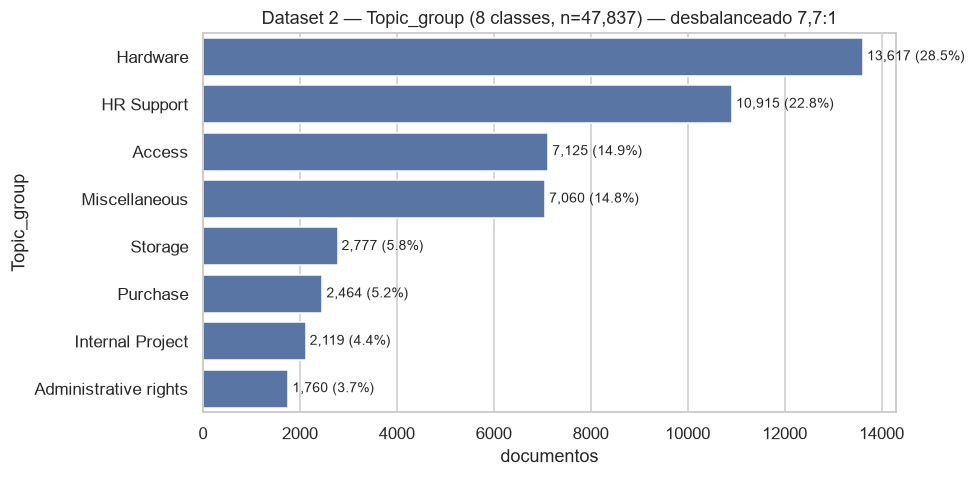

Razão de desbalanceamento (maior/menor classe): 7.7:1


In [15]:
vc = d2["Topic_group"].value_counts()
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(x=vc.values, y=vc.index, color=BLUE)
for i, v in enumerate(vc.values):
    ax.text(v, i, f" {v:,} ({v / len(d2) * 100:.1f}%)", va="center", fontsize=9)
ax.set_title(f"Dataset 2 — Topic_group ({vc.size} classes, n={len(d2):,}) — desbalanceado 7,7:1")
ax.set_xlabel("documentos")
plt.tight_layout()
plt.savefig(ASSETS / "d2_class_distribution.png", bbox_inches="tight")
plt.show()
print(f"Razão de desbalanceamento (maior/menor classe): {vc.max() / vc.min():.1f}:1")

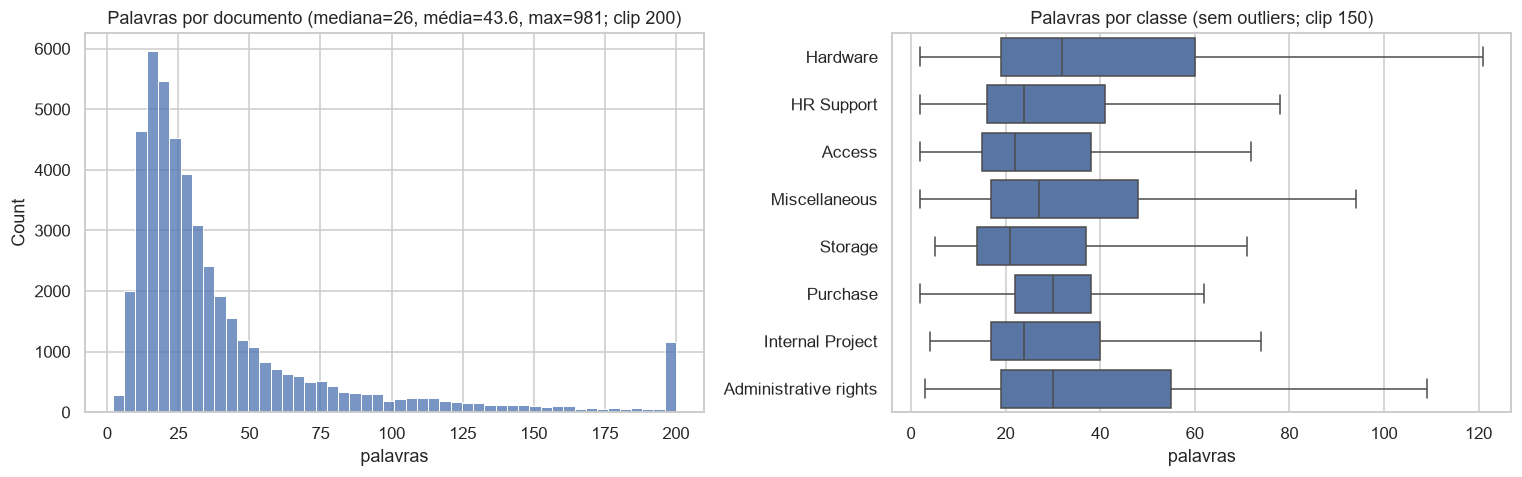

Docs com < 3 palavras: 14
Percentis de palavras [1,25,50,75,99]: [  6.  17.  26.  46. 284.]

Mediana de palavras por classe:
Topic_group
Storage                  21.0
Access                   22.0
Internal Project         24.0
HR Support               24.0
Miscellaneous            27.0
Administrative rights    30.0
Purchase                 30.0
Hardware                 32.0


In [16]:
wl = d2["Document"].str.split().str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(wl.clip(upper=200), bins=50, ax=axes[0], color=BLUE)
axes[0].set_title(f"Palavras por documento (mediana={wl.median():.0f}, média={wl.mean():.1f}, max={wl.max()}; clip 200)")
axes[0].set_xlabel("palavras")

sns.boxplot(x=wl.clip(upper=150), y=d2["Topic_group"], order=vc.index, ax=axes[1],
            color=BLUE, showfliers=False)
axes[1].set_title("Palavras por classe (sem outliers; clip 150)")
axes[1].set_xlabel("palavras"); axes[1].set_ylabel("")
fig.tight_layout()
fig.savefig(ASSETS / "d2_text_length.png", bbox_inches="tight")
plt.show()

print("Docs com < 3 palavras:", (wl < 3).sum())
print("Percentis de palavras [1,25,50,75,99]:", np.percentile(wl, [1, 25, 50, 75, 99]).round(0))
print("\nMediana de palavras por classe:")
print(d2.assign(w=wl).groupby("Topic_group")["w"].median().sort_values().to_string())

**Leitura:** Dataset 2 é **texto real** já pré-processado (minúsculas, sem pontuação/stopwords),
sem nulos e sem duplicatas. 8 classes com desbalanceamento 7,7:1 (Hardware 28,5% vs Administrative rights 3,7%) —
na FASE 5 isso pede **estratificação** no split e métricas por classe (macro-F1), não só accuracy.
14 documentos com <3 palavras são ruído residual desprezível (0,03%).

---
## 6. Síntese da auditoria

| # | Achado | Evidência | Impacto |
|---|--------|-----------|---------|
| 1 | Dataset 1 tem 8.469 tickets (não ~30k do brief) | contagem via parser | ROI extrapola com premissa explícita |
| 2 | Nulos 100% estruturais por status | crosstab determinístico | análises de satisfação/tempo usam só Closed (n=2.769) |
| 3 | **FRT/TTR são timestamps aleatórios, não durações** | 49,3% de deltas negativos; corr ≈ 0,06; 3 dias de calendário; delta triangular | tempos derivados são ruído — Hipóteses A e B rejeitadas |
| 4 | Distribuições categóricas e satisfação uniformes | qui-quadrado | correlações fracas esperadas; honestidade analítica na FASE 3 |
| 5 | Texto do Dataset 1 é template sintético | 100% com `{product_purchased}`, 16 aberturas | NLP de produção treina no Dataset 2 |
| 6 | Dataset 2 limpo, real, 8 classes desbalanceadas 7,7:1 | value_counts | usar split estratificado + macro-F1 na FASE 5 |

Conclusões completas e limitações: **`docs/data_audit.md`**.